In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)
torch.manual_seed(42)

plt.rcParams['figure.dpi'] = 100

## 1. Load clean features

In [ ]:
df = pd.read_csv('../data/battery_features_clean.csv')

# Cell8 only has 2 logged cycles -- not usable for train/test splitting
counts = df.groupby('cell')['cycle'].count()
usable_cells = counts[counts >= 10].index.tolist()
print("Usable cells:", usable_cells)
print("Dropped (too few cycles):", set(df['cell'].unique()) - set(usable_cells))

df = df[df['cell'].isin(usable_cells)].copy().sort_values(['cell', 'cycle'])
print("\nShape:", df.shape)
print("\nSOH range:", df['soh'].min().round(4), "-", df['soh'].max().round(4))
df.head()

Usable cells: ['Cell1', 'Cell2', 'Cell3', 'Cell4', 'Cell5', 'Cell6', 'Cell7']
Dropped (too few cycles): {'Cell8'}

Shape: (443, 11)

SOH range: 0.6203 - 1.0 (should be <= 1.0 -- no more impossible values)


,cell,cycle,q_min,q_max,n_samples,capacity,avg_temp,initial_capacity,soh,cum_ah_throughput,soh_smooth
0,Cell1,0,-739.110921,0.0,3608,739.110921,39.963427,739.110921,1.000000,739.110921,0.993967
1,Cell1,100,-730.192949,0.0,3565,730.192949,39.937610,739.110921,0.987934,1469.303870,0.989951
2,Cell1,200,-725.746738,0.0,3544,725.746738,39.968553,739.110921,0.981919,2195.050608,0.982614
3,Cell1,300,-722.843197,0.0,3530,722.843197,39.932417,739.110921,0.977990,2917.893805,0.977281
4,Cell1,400,-718.366896,0.0,3507,718.366896,39.959566,739.110921,0.971934,3636.260701,0.972425


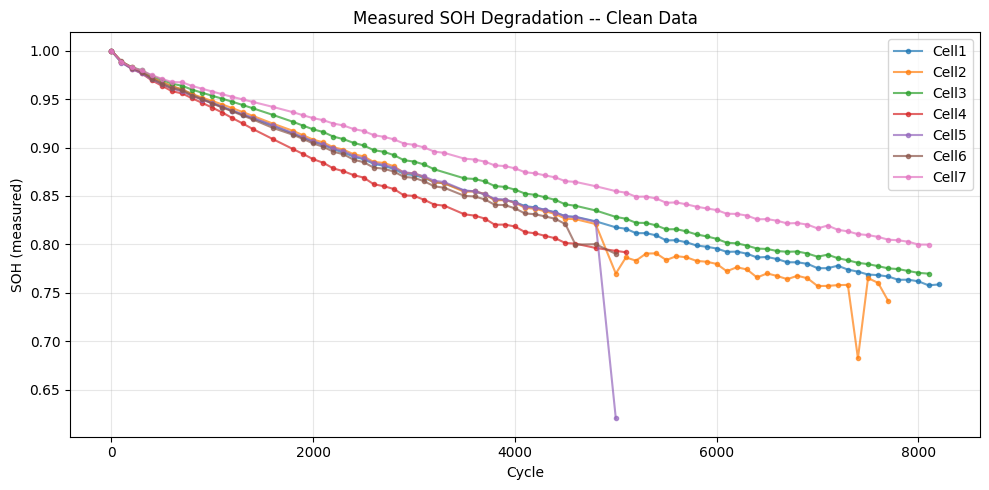

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
for cell, g in df.groupby('cell'):
    ax.plot(g['cycle'], g['soh'], marker='o', markersize=3, alpha=0.7, label=cell)
ax.set_xlabel('Cycle')
ax.set_ylabel('SOH (measured)')
ax.set_title('Measured SOH Degradation -- Clean Data')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Physics-Based Degradation Baseline

In [ ]:
df['cycle_norm'] = df['cycle'] / df.groupby('cell')['cycle'].transform('max')
df['throughput_norm'] = df['cum_ah_throughput'] / df.groupby('cell')['cum_ah_throughput'].transform('max')
df['temp_K'] = df['avg_temp'] + 273.15

T_ref = 313.15  # 40C reference
df['temperature_factor'] = np.exp(0.01 * (df['temp_K'] - T_ref))

alpha, beta = 0.15, 0.10
df['degradation'] = (alpha * df['cycle_norm'] + beta * df['throughput_norm']) * df['temperature_factor']
df['physics_soh'] = (1 - df['degradation']).clip(0, 1)

mae_p = mean_absolute_error(df['soh'], df['physics_soh'])
rmse_p = np.sqrt(mean_squared_error(df['soh'], df['physics_soh']))
r2_p = r2_score(df['soh'], df['physics_soh'])
print(f"Physics Baseline (all data)  ->  MAE={mae_p:.4f}  RMSE={rmse_p:.4f}  R2={r2_p:.4f}")

Physics Baseline (all data)  ->  MAE=0.0182  RMSE=0.0234  R2=0.8799


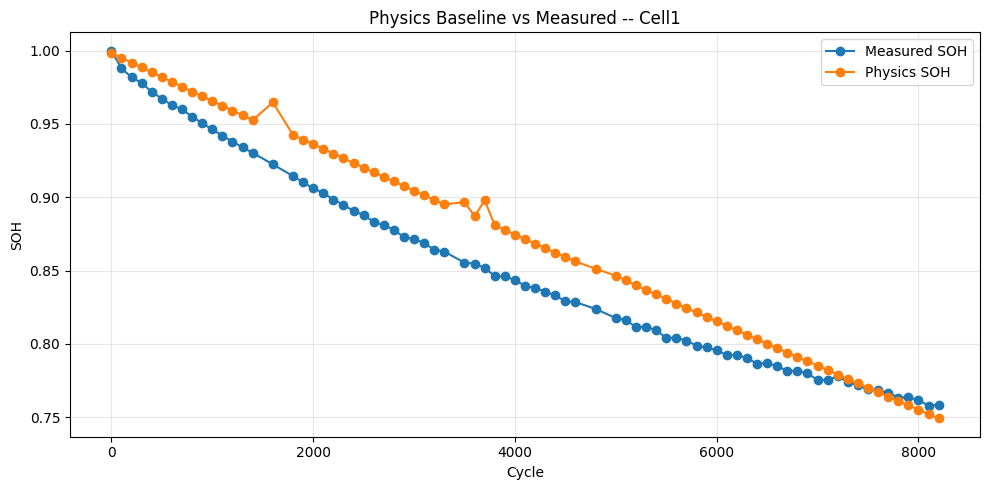

In [ ]:
cell_to_plot = 'Cell1'
plot_df = df[df['cell'] == cell_to_plot].sort_values('cycle')

plt.figure(figsize=(10, 5))
plt.plot(plot_df['cycle'], plot_df['soh'], marker='o', label='Measured SOH')
plt.plot(plot_df['cycle'], plot_df['physics_soh'], marker='o', label='Physics SOH')
plt.xlabel('Cycle')
plt.ylabel('SOH')
plt.title(f'Physics Baseline vs Measured -- {cell_to_plot}')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Hybrid Physics-Informed Neural Network

The NN learns a **residual correction** on top of the physics prediction:

`SOH_hybrid = SOH_physics + NN(features)`

Trained with a data-fit loss plus a physics-consistency penalty (`mean(residual^2)`) that discourages the network from drifting far from the physics prior -- this is what keeps it from overfitting noise.

Features are the same normalized quantities the physics model uses, so the residual has a consistent basis to correct against.

In [ ]:
feature_cols = ['cycle_norm', 'throughput_norm', 'temperature_factor']

class ResidualNN(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 16), nn.Tanh(), nn.Dropout(0.15),
            nn.Linear(16, 8), nn.Tanh(),
            nn.Linear(8, 1)
        )
    def forward(self, x):
        return self.net(x)

class PlainNN(nn.Module):
    """Pure black-box baseline -- same capacity, no physics term, for comparison."""
    def __init__(self, input_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 16), nn.Tanh(), nn.Dropout(0.15),
            nn.Linear(16, 8), nn.Tanh(),
            nn.Linear(8, 1)
        )
    def forward(self, x):
        return self.net(x)

def train_hybrid(Xtr, ytr, ptr, Xval, yval, pval, phys_weight=0.3, lr=0.01, wd=1e-3, patience=150, max_epochs=3000):
    model = ResidualNN(Xtr.shape[1])
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    loss_fn = nn.MSELoss()
    best_val, best_state, ctr = float('inf'), None, 0
    for epoch in range(max_epochs):
        model.train(); opt.zero_grad()
        residual = model(Xtr)
        pred = ptr + residual
        loss = loss_fn(pred, ytr) + phys_weight * torch.mean(residual ** 2)
        loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            vloss = loss_fn(pval + model(Xval), yval).item()
        if vloss < best_val:
            best_val, best_state, ctr = vloss, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            ctr += 1
            if ctr > patience:
                break
    model.load_state_dict(best_state)
    model.eval()
    return model

def train_plain(Xtr, ytr, Xval, yval, lr=0.01, wd=1e-3, patience=150, max_epochs=3000):
    model = PlainNN(Xtr.shape[1])
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    loss_fn = nn.MSELoss()
    best_val, best_state, ctr = float('inf'), None, 0
    for epoch in range(max_epochs):
        model.train(); opt.zero_grad()
        loss = loss_fn(model(Xtr), ytr)
        loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            vloss = loss_fn(model(Xval), yval).item()
        if vloss < best_val:
            best_val, best_state, ctr = vloss, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            ctr += 1
            if ctr > patience:
                break
    model.load_state_dict(best_state)
    model.eval()
    return model

def to_tensors(train_df, test_df, scaler=None):
    if scaler is None:
        scaler = StandardScaler().fit(train_df[feature_cols])
    Xtr_np = scaler.transform(train_df[feature_cols])
    Xte_np = scaler.transform(test_df[feature_cols])
    Xtr = torch.tensor(Xtr_np, dtype=torch.float32)
    ytr = torch.tensor(train_df['soh'].values, dtype=torch.float32).view(-1, 1)
    ptr = torch.tensor(train_df['physics_soh'].values, dtype=torch.float32).view(-1, 1)
    Xte = torch.tensor(Xte_np, dtype=torch.float32)
    yte = test_df['soh'].values
    pte = torch.tensor(test_df['physics_soh'].values, dtype=torch.float32).view(-1, 1)
    return Xtr, ytr, ptr, Xte, yte, pte, scaler

def val_split(Xtr, ytr, ptr, frac=0.15, seed=42):
    rng = np.random.RandomState(seed)
    n = len(Xtr)
    idx = rng.permutation(n)
    val_n = max(10, int(frac * n))
    val_idx, tr_idx = idx[:val_n], idx[val_n:]
    return Xtr[tr_idx], ytr[tr_idx], ptr[tr_idx], Xtr[val_idx], ytr[val_idx], ptr[val_idx]

def metrics(y_true, y_pred):
    return (mean_absolute_error(y_true, y_pred),
            np.sqrt(mean_squared_error(y_true, y_pred)),
            r2_score(y_true, y_pred))

### 3a. Evaluation Regime 1 -- Standard Held-Out Test (random 80/20 split)

This is the typical "how accurate is the model on unseen-but-similar data" check.

In [ ]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

Xtr, ytr, ptr, Xte, y_test, pte, scaler = to_tensors(train_df, test_df)
Xtr_fit, ytr_fit, ptr_fit, Xval, yval, pval = val_split(Xtr, ytr, ptr)

mae_p, rmse_p, r2_p = metrics(y_test, pte.numpy().flatten())

hybrid_model = train_hybrid(Xtr_fit, ytr_fit, ptr_fit, Xval, yval, pval)
with torch.no_grad():
    pred_hybrid = (pte + hybrid_model(Xte)).numpy().flatten()
mae_h, rmse_h, r2_h = metrics(y_test, pred_hybrid)

plain_model = train_plain(Xtr_fit, ytr_fit, Xval, yval)
with torch.no_grad():
    pred_plain = plain_model(Xte).numpy().flatten()
mae_pl, rmse_pl, r2_pl = metrics(y_test, pred_plain)

results_random = pd.DataFrame({
    'Model': ['Physics Baseline', 'Hybrid PINN', 'Plain NN (no physics)'],
    'MAE': [mae_p, mae_h, mae_pl],
    'RMSE': [rmse_p, rmse_h, rmse_pl],
    'R2': [r2_p, r2_h, r2_pl]
})
print("Regime 1: Standard held-out test (random split)")
results_random.round(4)

Regime 1: Standard held-out test (random split)


,Model,MAE,RMSE,R2
0,Physics Baseline,0.0188,0.0230,0.8928
1,Hybrid PINN,0.0167,0.0203,0.9168
2,Plain NN (no physics),0.0176,0.0206,0.9142


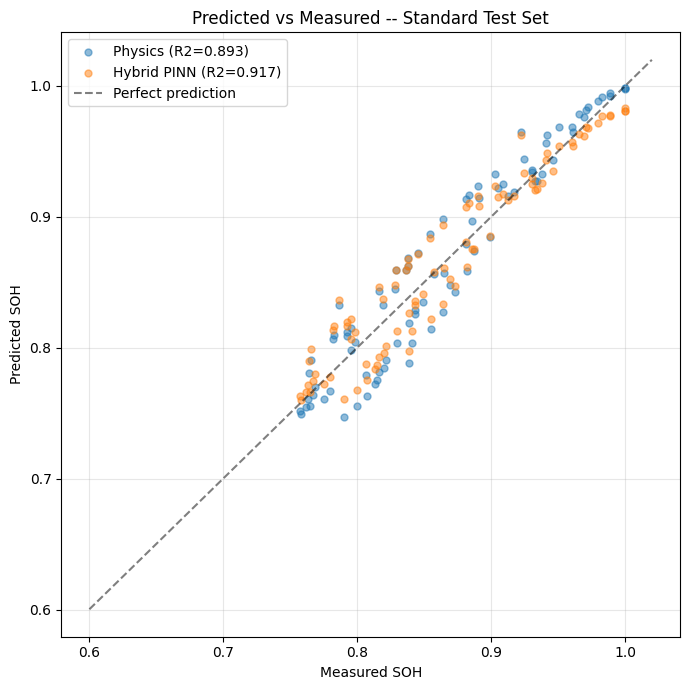

In [ ]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, pte.numpy().flatten(), alpha=0.5, label=f'Physics (R2={r2_p:.3f})', s=25)
plt.scatter(y_test, pred_hybrid, alpha=0.5, label=f'Hybrid PINN (R2={r2_h:.3f})', s=25)
lims = [df['soh'].min() - 0.02, df['soh'].max() + 0.02]
plt.plot(lims, lims, 'k--', alpha=0.5, label='Perfect prediction')
plt.xlabel('Measured SOH')
plt.ylabel('Predicted SOH')
plt.title('Predicted vs Measured -- Standard Test Set')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
print("=== FINAL RESULTS TABLE ===\n")
print("Regime 1 (standard test):")
print(results_random.round(4).to_string(index=False))
print("\nRegime 2 (OOD extrapolation):")
print(results_ood.round(4).to_string(index=False))

=== FINAL RESULTS TABLE ===

Regime 1 (standard test):
                Model    MAE   RMSE     R2
     Physics Baseline 0.0188 0.0230 0.8928
          Hybrid PINN 0.0167 0.0203 0.9168
Plain NN (no physics) 0.0176 0.0206 0.9142

Regime 2 (OOD extrapolation):
                Model    MAE   RMSE      R2
     Physics Baseline 0.0274 0.0351 -0.1077
          Hybrid PINN 0.0282 0.0358 -0.1552
Plain NN (no physics) 0.0303 0.0378 -0.2835
